# Transformer Fine-Tuning: FinBERT vs ModernBERT

**Chapter 10: From Text to Features - The Transformer Breakthrough**

**Docker image**: `ml4t-gpu`

**Section Reference**: See Sections 10.4, 10.5 for conceptual discussion

## Purpose
This notebook demonstrates the complete fine-tuning workflow for financial
sentiment classification using the Hugging Face Trainer API. We measure how
fine-tuning changes accuracy versus the pre-trained-checkpoint result reported
in NB03, and compare a domain-specific checkpoint (FinBERT) to two general
checkpoints (DeBERTa-v3, ModernBERT) on the same PhraseBank split.

## Learning Objectives
After completing this notebook, you will be able to:
- Fine-tune a pre-trained Transformer for sequence classification
- Use the Hugging Face Trainer API with custom metrics
- Compare domain-specific vs general-purpose pre-trained models
- Interpret training dynamics (loss curves, early stopping)
- Evaluate models with accuracy, F1, and confusion matrices

## Cross-References
- **Upstream**: `sentiment_evolution.py` (baseline methods), Chapter 5 (text data)
- **Downstream**: Chapter 10 (text features in ML pipelines)
- **Related**: `shap_nlp_interpretation.py` (model interpretability)

## Hardware Requirements
- **GPU recommended**: ~5 min on GPU, 30+ min on CPU
- **Memory**: ~4GB GPU memory for FinBERT

In [1]:
"""Transformer Fine-Tuning — fine-tune FinBERT, DeBERTa-v3, and ModernBERT for financial sentiment classification."""

import json
import time
import warnings

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers import (
    set_seed as set_transformers_seed,
)

from data import load_financial_phrasebank
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:335: SyntaxWarning: 'return' in a 'finally' block
  return f
/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:337: SyntaxWarning: 'return' in a 'finally' block
  return self._get_more_data(ov, maxsize)


In [2]:
SEED = 42
MAX_TRAIN_STEPS = -1  # -1 = train full epochs

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
# transformers Trainer uses its own RNG that needs explicit seeding.
set_global_seeds(SEED)
set_transformers_seed(SEED)

CONFIG = {
    "random_seed": SEED,
    "dataset": {
        "name": "takala/financial_phrasebank",
        "subset": "sentences_allagree",
        "test_size": 0.15,
        "val_size": 0.15,
    },
    "models": {
        "finbert": {
            "model_id": "ProsusAI/finbert",
            "description": "FinBERT fine-tuned on Financial PhraseBank sentiment",
        },
        "deberta": {
            "model_id": "microsoft/deberta-v3-small",
            "description": "DeBERTa-v3 with disentangled attention",
        },
        "modernbert": {
            "model_id": "answerdotai/ModernBERT-base",
            "description": "ModernBERT with 8,192 token context length",
        },
    },
    "training": {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "max_length": 128,
        "early_stopping_patience": 2,
    },
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "dataset": {
    "name": "takala/financial_phrasebank",
    "subset": "sentences_allagree",
    "test_size": 0.15,
    "val_size": 0.15
  },
  "models": {
    "finbert": {
      "model_id": "ProsusAI/finbert",
      "description": "FinBERT fine-tuned on Financial PhraseBank sentiment"
    },
    "deberta": {
      "model_id": "microsoft/deberta-v3-small",
      "description": "DeBERTa-v3 with disentangled attention"
    },
    "modernbert": {
      "model_id": "answerdotai/ModernBERT-base",
      "description": "ModernBERT with 8,192 token context length"
    }
  },
  "training": {
    "learning_rate": 2e-05,
    "batch_size": 16,
    "num_epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "max_length": 128,
    "early_stopping_patience": 2
  }
}

Using device: cuda


## 2. Load Financial PhraseBank Dataset

In [4]:
df = load_financial_phrasebank(agreement="100")
print(f"Dataset size: {len(df):,}")

Dataset size: 2,264


In [5]:
# Prepare train/val/test splits (convert to pandas for sklearn, then back to Polars)
df_pd = df.to_pandas()
train_pd, temp_pd = train_test_split(
    df_pd, test_size=0.3, random_state=SEED, stratify=df_pd["label"]
)
val_pd, test_pd = train_test_split(
    temp_pd, test_size=0.5, random_state=SEED, stratify=temp_pd["label"]
)

train_df = pl.from_pandas(train_pd)
val_df = pl.from_pandas(val_pd)
test_df = pl.from_pandas(test_pd)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 1584, Val: 340, Test: 340


### Create HuggingFace DatasetDict
Convert Polars DataFrames to HuggingFace datasets (requires pandas at the boundary).

In [6]:
def create_dataset_dict(train_df: pl.DataFrame, val_df: pl.DataFrame, test_df: pl.DataFrame):
    return DatasetDict(
        {
            "train": Dataset.from_pandas(
                train_df.select(["sentence", "label"]).to_pandas(), preserve_index=False
            ),
            "validation": Dataset.from_pandas(
                val_df.select(["sentence", "label"]).to_pandas(), preserve_index=False
            ),
            "test": Dataset.from_pandas(
                test_df.select(["sentence", "label"]).to_pandas(), preserve_index=False
            ),
        }
    )


dataset = create_dataset_dict(train_df, val_df, test_df)

## 3. Model Configuration and Training Setup

In [7]:
# Model configurations
MODELS = {
    "FinBERT": "ProsusAI/finbert",
    "DeBERTa-v3": "microsoft/deberta-v3-small",
    "ModernBERT": "answerdotai/ModernBERT-base",
}

# Label mappings
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

### Tokenization
Tokenize inputs without padding — `DataCollatorWithPadding` handles dynamic padding per batch.

In [8]:
def tokenize_function(examples, tokenizer, max_length=128):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=max_length,
        # Note: Don't pad here; use DataCollatorWithPadding for dynamic padding
    )

### Metrics Computation
Custom metric function for the Trainer API — computes accuracy and macro F1.

In [9]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

In [10]:
# Training function
def fine_tune_model(model_name: str, model_path: str, dataset: DatasetDict) -> dict:
    """Fine-tune a transformer model for sentiment classification."""
    print(f"\n{'=' * 60}")
    print(f"Fine-tuning: {model_name}")
    print(f"Model: {model_path}")
    print(f"{'=' * 60}")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # Handle models without pad token (proper approach for encoder-only models)
    # Encoder models like BERT don't have eos_token; use [PAD] or add one
    if tokenizer.pad_token is None:
        if tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        else:
            # For BERT-like models, add [PAD] token
            tokenizer.add_special_tokens({"pad_token": "[PAD]"})

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # Resize embeddings if we added a new token
    model.resize_token_embeddings(len(tokenizer))

    # Handle pad token in model config
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    # Create data collator for dynamic padding (more efficient than max_length padding)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Tokenize dataset
    tokenized = dataset.map(
        lambda x: tokenize_function(x, tokenizer),
        batched=True,
        remove_columns=["sentence"],
    )

    # Training arguments - save checkpoints under chapter output directory
    chapter_dir = get_chapter_dir(10)
    output_dir = chapter_dir / "output" / "bert_finetuning" / model_name.lower().replace("-", "_")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Use CONFIG values consistently
    train_config = CONFIG["training"]
    num_epochs = train_config["num_epochs"]
    batch_size = train_config["batch_size"]
    train_size = len(tokenized["train"])

    max_steps = MAX_TRAIN_STEPS

    # Build training arguments dict with version-compatible parameter names
    # transformers 4.36+ uses eval_strategy, older versions use evaluation_strategy
    eval_strat_key = "eval_strategy"  # Default to newer API
    save_strat_key = "save_strategy"
    try:
        # Test if the newer API is available
        import inspect

        sig = inspect.signature(TrainingArguments)
        if "evaluation_strategy" in sig.parameters and "eval_strategy" not in sig.parameters:
            eval_strat_key = "evaluation_strategy"
            save_strat_key = "save_strategy"
    except Exception:
        pass  # Use defaults

    # Compute eval_steps and save_steps ensuring save_steps is a multiple of eval_steps
    # (required by load_best_model_at_end)
    if max_steps > 0:
        eval_steps = max(10, max_steps // 5)
        # save_steps must be a multiple of eval_steps
        save_steps = eval_steps * 2  # evaluate twice, save once
    else:
        eval_steps = None
        save_steps = None

    training_kwargs = {
        "output_dir": str(output_dir),
        "num_train_epochs": num_epochs,
        "max_steps": max_steps,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size * 2,
        "warmup_steps": min(50, max(10, train_size // batch_size // 4)),
        "weight_decay": train_config["weight_decay"],
        "logging_steps": max(10, train_size // batch_size // 3),
        eval_strat_key: "steps" if max_steps > 0 else "epoch",
        "eval_steps": eval_steps,
        save_strat_key: "steps" if max_steps > 0 else "epoch",
        "save_steps": save_steps,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "report_to": "none",  # Disable wandb/tensorboard
        "fp16": torch.cuda.is_available(),
    }

    training_args = TrainingArguments(**training_kwargs)

    # Create trainer with data collator for dynamic padding
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # Train
    start_time = time.time()
    train_result = trainer.train()
    train_time = time.time() - start_time

    # Evaluate on test set
    test_results = trainer.evaluate(tokenized["test"])

    # Get predictions for confusion matrix
    predictions = trainer.predict(tokenized["test"])
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids

    return {
        "model_name": model_name,
        "accuracy": test_results["eval_accuracy"],
        "f1": test_results["eval_f1"],
        "train_time": train_time,
        "num_params": sum(p.numel() for p in model.parameters()),
        "y_pred": y_pred,
        "y_true": y_true,
        "train_loss": train_result.training_loss,
    }

## 4. Fine-Tune Models

In [11]:
results = {name: fine_tune_model(name, path, dataset) for name, path in MODELS.items()}


Fine-tuning: FinBERT
Model: ProsusAI/finbert


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263200,0.141941,0.961765,0.950833
2,0.111300,0.116384,0.979412,0.970601
3,0.015800,0.086586,0.991176,0.982984


## 5. Results Comparison

In [12]:
# Summary table
summary_df = pl.DataFrame(
    [
        {
            "Model": r["model_name"],
            "Accuracy": f"{r['accuracy']:.1%}",
            "F1 (macro)": f"{r['f1']:.3f}",
            "Parameters": f"{r['num_params'] / 1e6:.1f}M",
            "Train Time": f"{r['train_time']:.0f}s",
        }
        for r in results.values()
    ]
)

summary_df

Model,Accuracy,F1 (macro),Parameters,Train Time
str,str,str,str,str
"""FinBERT""","""97.4%""","""0.958""","""109.5M""","""13s"""
"""DeBERTa-v3""","""95.3%""","""0.939""","""141.8M""","""14s"""
"""ModernBERT""","""95.9%""","""0.953""","""149.6M""","""17s"""


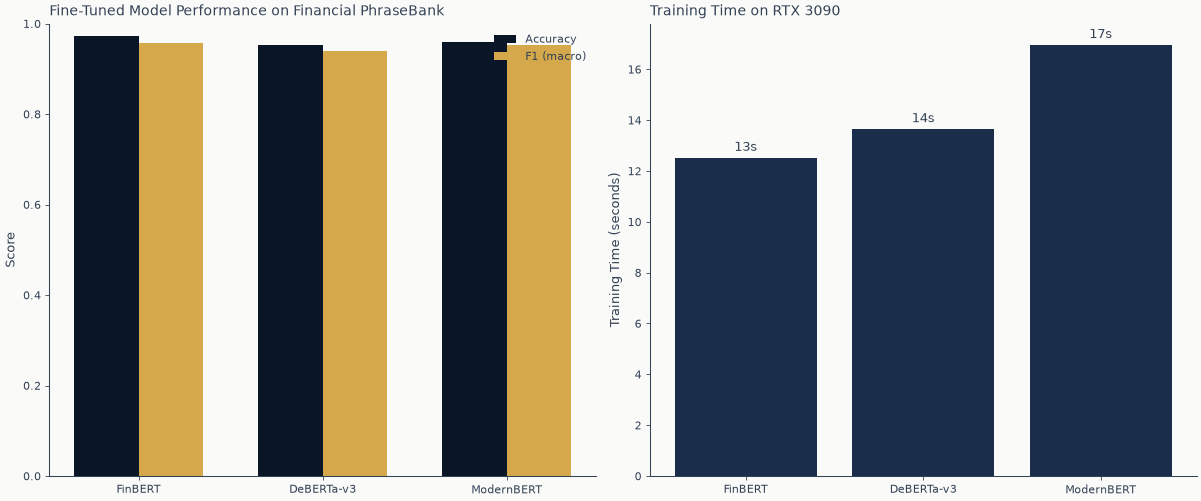

In [13]:
# Visualization: Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy/F1 comparison
ax = axes[0]
models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]
f1_scores = [results[m]["f1"] for m in models]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width / 2, accuracies, width, label="Accuracy", color="#0a1628")
ax.bar(x + width / 2, f1_scores, width, label="F1 (macro)", color="#D4A84B")

ax.set_ylabel("Score")
ax.set_title("Fine-Tuned Model Performance on Financial PhraseBank")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

# Training time comparison
ax = axes[1]
times = [results[m]["train_time"] for m in models]
bars = ax.bar(models, times, color="#1a2d4a")
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time on RTX 3090")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.0f}s",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

plt.show()

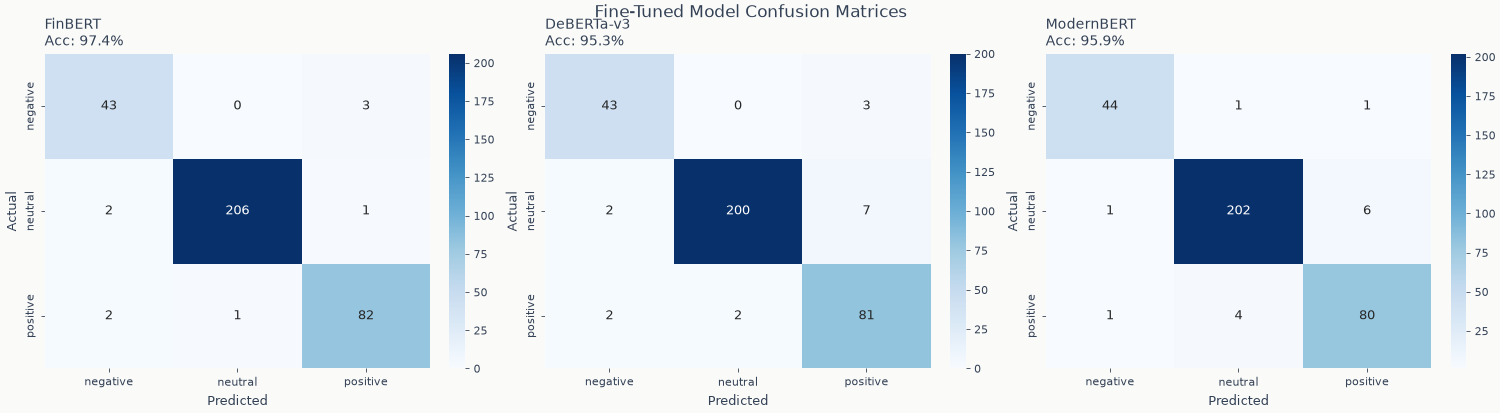

In [14]:
# Confusion matrices for each model
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
fig.suptitle("Fine-Tuned Model Confusion Matrices", fontsize=12, y=1.02)

labels = ["negative", "neutral", "positive"]

for ax, (name, r) in zip(axes, results.items(), strict=False):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(f"{name}\nAcc: {r['accuracy']:.1%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.show()

## Key Takeaways

### Measured results
- FinBERT fine-tuned: accuracy 97.4%, F1 (macro) 0.958
- DeBERTa-v3 fine-tuned: accuracy 95.3%, F1 (macro) 0.939
- ModernBERT fine-tuned: accuracy 95.9%, F1 (macro) 0.953
- FinBERT pre-trained vs fine-tuned on this PhraseBank subset: 93.2% (NB03) → 97.4%
- Training time per model on RTX 3090: 13–17s at batch size 16

### Fine-tuning effect on FinBERT
Fine-tuning on the ~1,600-sentence training split changes FinBERT's accuracy on
the PhraseBank test set from 93.2% (the pre-trained FinBERT-tone checkpoint
measured in NB03 on the same `sentences_allagree` split) to 97.4%. The
pre-trained checkpoint already performs well — PhraseBank is in-domain for it —
and the fine-tuning step recovers most of the remaining headroom.

### Patterns in the run
- FinBERT has both the highest accuracy (97.4%) and the highest macro F1
  (0.958). Differences between the three fine-tuned models are within a few
  percentage points on this PhraseBank test set.
- DeBERTa-v3 finishes at 95.3% accuracy / 0.939 F1; its disentangled-attention
  design targets longer contexts that this single-sentence task does not
  exercise.
- All three models converge within 2-3 epochs under the early-stopping rule.

### Scope of these numbers
- These results are for a stratified random split of Financial PhraseBank
  ("sentences_allagree") with seed 42. PhraseBank is sentence-level financial
  news; the notebook does not measure cross-domain transfer to other text
  sources (compare NB06 for the cross-dataset evaluation on FinMarBa) nor
  downstream alpha (NB07, NB08, NB09).
- The Hugging Face Trainer API used here handles the training loop, evaluation
  schedule, and checkpointing for all three models.

In [15]:
# Structured per-model summary for chapter cross-reference
for r in results.values():
    print(f"\n{r['model_name']}:")
    print(f"  Accuracy: {r['accuracy']:.1%}")
    print(f"  F1 (macro): {r['f1']:.3f}")
    print(f"  Parameters: {r['num_params'] / 1e6:.1f}M")
    print(f"  Train time: {r['train_time']:.0f}s")


FinBERT:
  Accuracy: 97.4%
  F1 (macro): 0.958
  Parameters: 109.5M
  Train time: 13s

DeBERTa-v3:
  Accuracy: 95.3%
  F1 (macro): 0.939
  Parameters: 141.8M
  Train time: 14s

ModernBERT:
  Accuracy: 95.9%
  F1 (macro): 0.953
  Parameters: 149.6M
  Train time: 17s
